In [4]:
import os
from ultralytics import YOLO, settings

import shutil
from IPython.display import Image, display
import glob
import cv2

In [5]:
settings.update({'runs_dir': './runs'})

dataset_yaml = '../dataset_banana/data.yaml'

if os.path.exists(dataset_yaml):
    print(f"Arquivo encontrado: {dataset_yaml}")
else:
    print(f"Arquivo NÃO encontrado: {dataset_yaml}. Ajuste o caminho ou baixe o dataset.")

Arquivo encontrado: ../dataset_banana/data.yaml


In [6]:
model = YOLO('yolov8n.pt')

results = model.train(data=dataset_yaml, epochs=5, imgsz=416, batch=2)

Ultralytics 8.4.48 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_banana/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

Analisando resultados da pasta: runs/detect/train-2
Amostra de Validação:


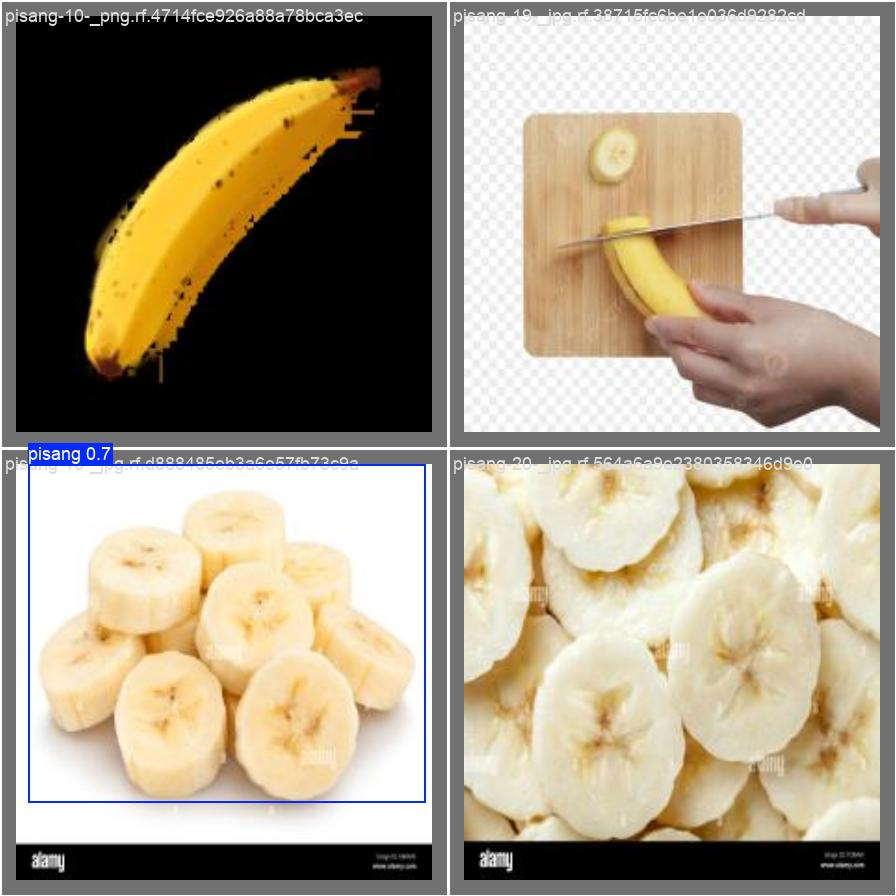


Gráficos de Treinamento:


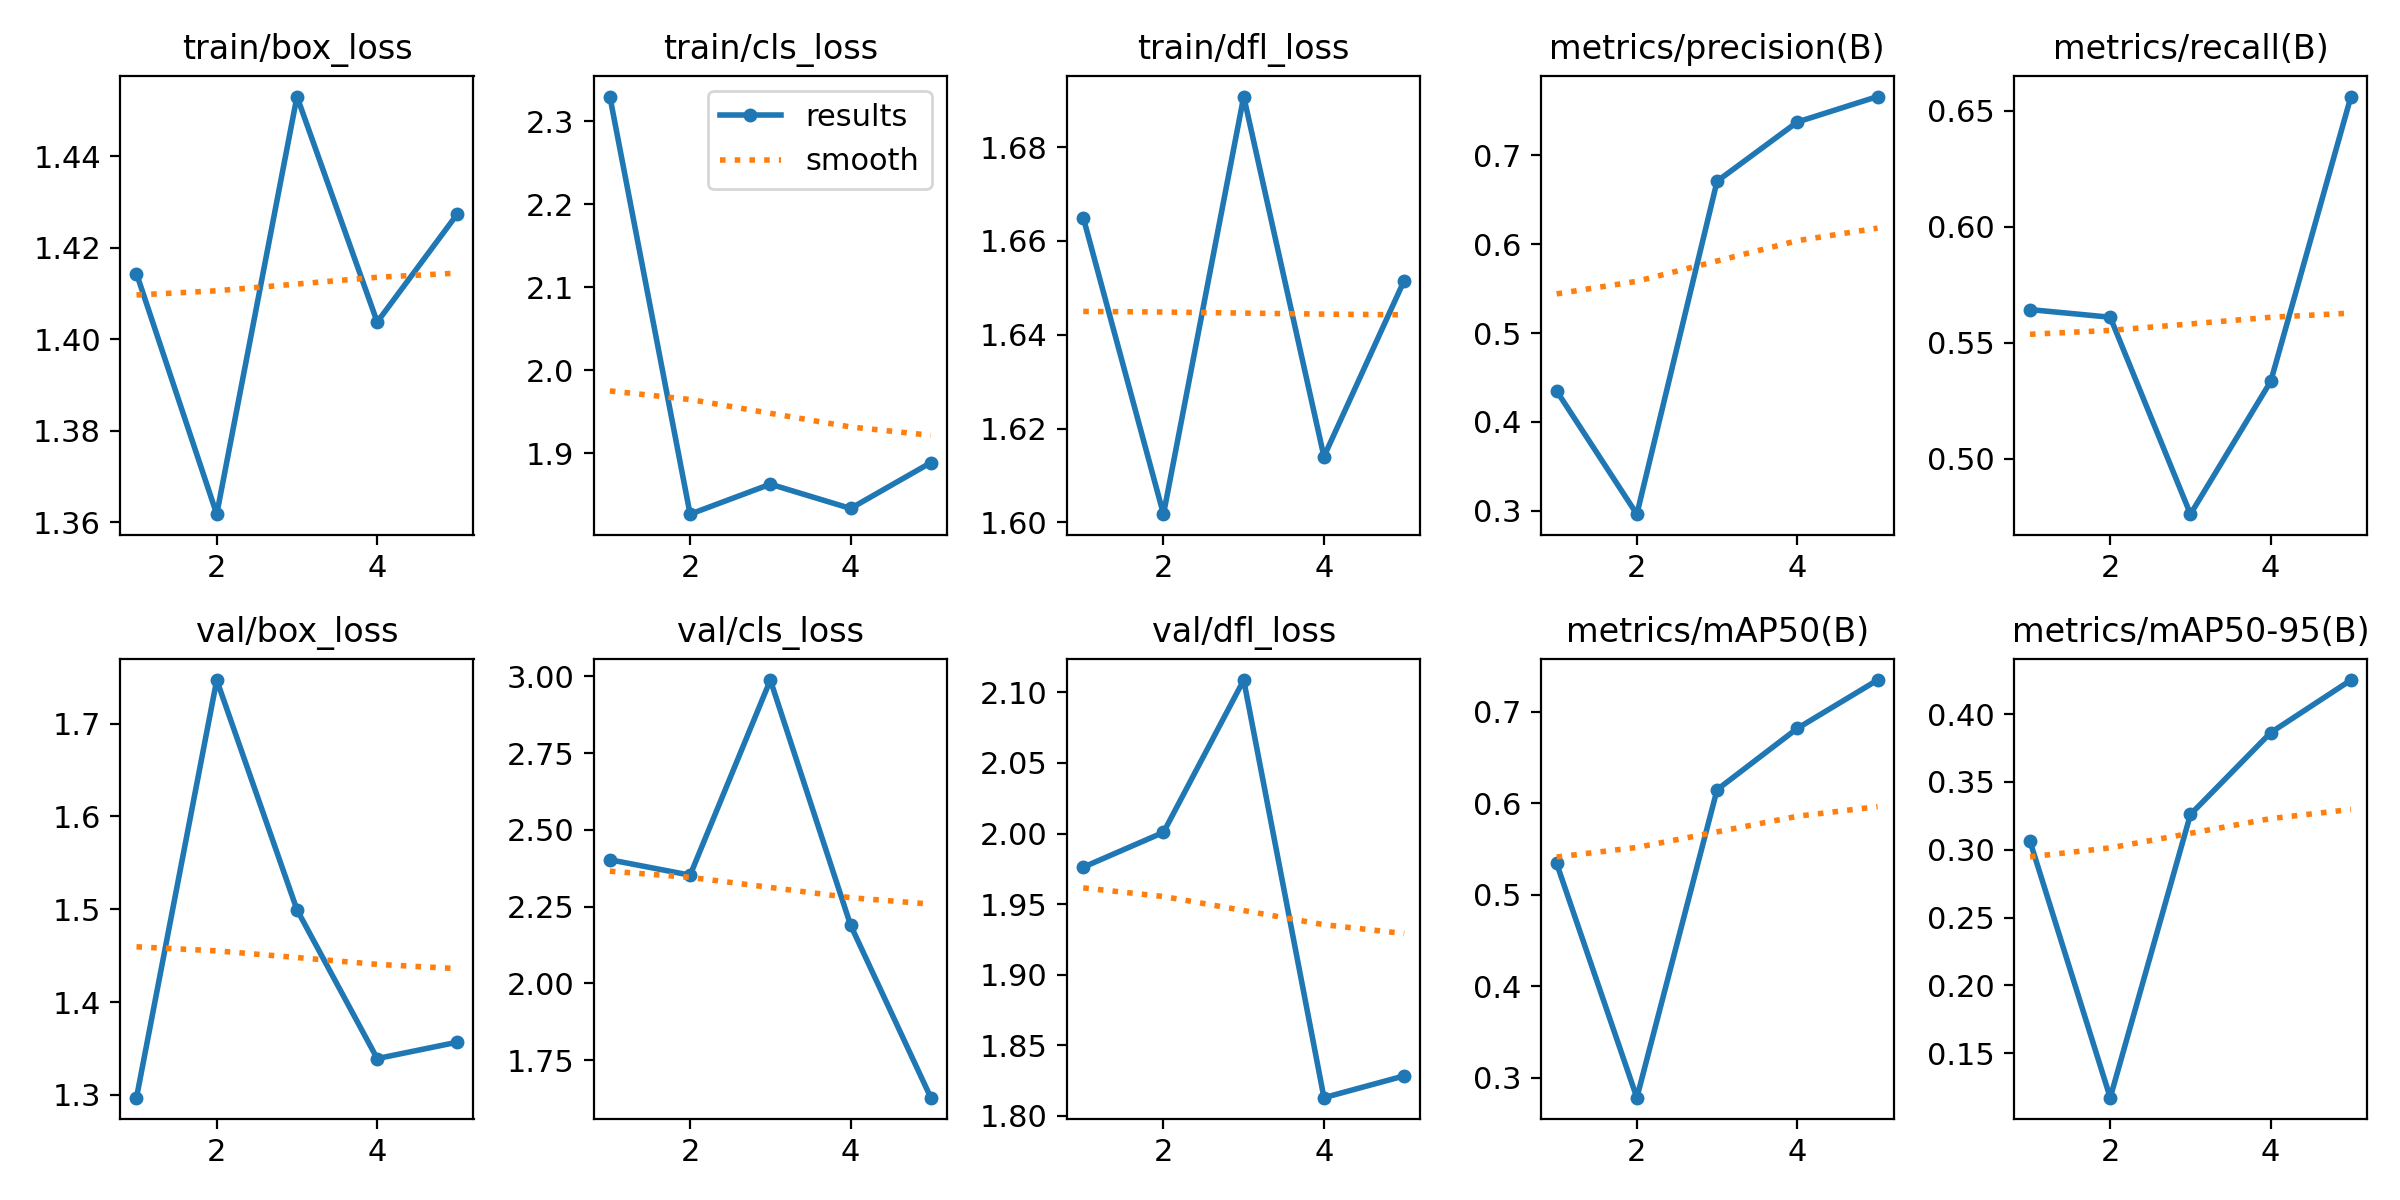

In [7]:
list_of_runs = glob.glob('runs/detect/train*')
latest_run = max(list_of_runs, key=os.path.getctime) if list_of_runs else None

if latest_run:
    print(f"Analisando resultados da pasta: {latest_run}")
    
    val_img = os.path.join(latest_run, 'val_batch0_pred.jpg')
    if os.path.exists(val_img):
        print("Amostra de Validação:")
        display(Image(filename=val_img, width=800))
        
    results_img = os.path.join(latest_run, 'results.png')
    if os.path.exists(results_img):
        print("\nGráficos de Treinamento:")
        display(Image(filename=results_img, width=800))
else:
    print("Nenhum resultado de treino encontrado ainda.")

In [8]:
shutil.copy(
    f"{results.save_dir}/weights/best.pt",
    "dataset_banana.pt"
)

print("Modelo salvo como dataset_banana.pt")

Modelo salvo como dataset_banana.pt
